# Лабораторная работа №2. Кластеризация клиентов интернет-магазина

#### Цель

- освоить методы k-means и агломеративной кластеризации на большом реальном датасете
транзакций
- научиться применять RFM-анализ для сегментации клиентов
- определять оптимальное число кластеров с помощью метода локтя и силуэтного анализа
- интерпретировать кластеры как бизнес-сегменты

#### Датасет

Online Retail по покупкам в интернет-магазине, локализованном в регионе с
индексом 1, пользователями из 39 регионов - 541 909 транзакций, 4 372 клиента, по ссылке
https://docs.google.com/spreadsheets/d/1liM0yHn0kFEBJppNjbjpf87wFKeSLvnx/edit?usp=sharing&ouid=114596079979601215791&rtpof=true&sd=true

#### Задача

Сегментировать клиентов по их покупательскому поведению, чтобы отдел маркетинга мог запускать таргетированные кампании: удерживать «ценных», реактивировать «спящих», стимулировать «новичков».

#### Признаки

| Признак | Описание |
|---|---|
| **InvoiceNo** | Номер счёта (6 цифр, уникальный для каждой транзакции) |
| **StockCode** | Код товара (5 цифр) |
| **Description** | Название товара |
| **Quantity** | Количество единиц товара в транзакции |
| **InvoiceDate** | Дата и время выставления счёта |
| **UnitPrice** | Цена за единицу товара |
| **CustomerID** | Идентификатор клиента (5 цифр) |
| **Region** | Код региона проживания клиента |

## Задание 1. Загрузка и EDA

In [186]:
import pandas as pd

In [187]:
df = pd.read_excel('https://docs.google.com/spreadsheets/d/1liM0yHn0kFEBJppNjbjpf87wFKeSLvnx/export?format=xlsx&id=1liM0yHn0kFEBJppNjbjpf87wFKeSLvnx')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Region
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2024-12-01 08:26:00,285.60,17850.0,1
1,536365,71053,WHITE METAL LANTERN,6,2024-12-01 08:26:00,379.68,17850.0,1
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2024-12-01 08:26:00,308.00,17850.0,1
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2024-12-01 08:26:00,379.68,17850.0,1
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2024-12-01 08:26:00,379.68,17850.0,1


In [188]:
print(f'Строк: {len(df)}')
print(f'Пропуски:\n{df.isna().sum()}')
df = df.dropna(subset=['CustomerID'])
df['CustomerID'] = df['CustomerID'].astype(int)
df_returns = df[df['Quantity'] <= 0].copy()
df = df[(df['Quantity'] > 0) | (df['UnitPrice'] > 0)].copy()
print('\n')
print('ПОСЛЕ ОЧИСТКИ')
print(f'Покупок: {len(df)}')
print(f'Возвратов: {len(df_returns)}')
print(f'Уникальных клиентов: {df['CustomerID'].nunique()}')

df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

Строк: 541909
Пропуски:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Region              0
dtype: int64


ПОСЛЕ ОЧИСТКИ
Покупок: 406829
Возвратов: 8905
Уникальных клиентов: 4372


In [189]:
df[['Quantity', 'UnitPrice', 'TotalPrice']].describe()

,Quantity,UnitPrice,TotalPrice
count,406829.000000,4.068290e+05,4.068290e+05
mean,12.061303,3.875728e+02,2.285008e+03
std,248.693370,7.763298e+03,4.789027e+04
min,-80995.000000,0.000000e+00,-1.886860e+07
25%,2.000000,1.400000e+02,4.704000e+02
50%,5.000000,2.184000e+02,1.243200e+03
75%,12.000000,4.200000e+02,2.184000e+03
max,80995.000000,4.364640e+06,1.886860e+07


Видно большой std относительно mean - большой разброс.
max сильно больше 75% - выбросы.

In [190]:
df['Region'].value_counts().head(10)

Region
1     361878
9       9495
2       8491
5       7485
7       2533
4       2371
13      2069
22      1877
28      1480
3       1259
Name: count, dtype: int64

По числу транзакций доминирует регион 1.

In [191]:
import matplotlib.pyplot as plt

%matplotlib inline

In [192]:
monthly = df.set_index('InvoiceDate').resample('ME')['TotalPrice'].sum()
print(monthly)

InvoiceDate
2024-12-31    6.211565e+07
2025-01-31    5.320833e+07
2025-02-28    4.889317e+07
2025-03-31    6.495604e+07
2025-04-30    4.771736e+07
2025-05-31    7.260412e+07
2025-06-30    6.809747e+07
2025-07-31    6.431471e+07
2025-08-31    6.903322e+07
2025-09-30    1.043213e+08
2025-10-31    1.091556e+08
2025-11-30    1.268297e+08
2025-12-31    3.836071e+07
Freq: ME, Name: TotalPrice, dtype: float64


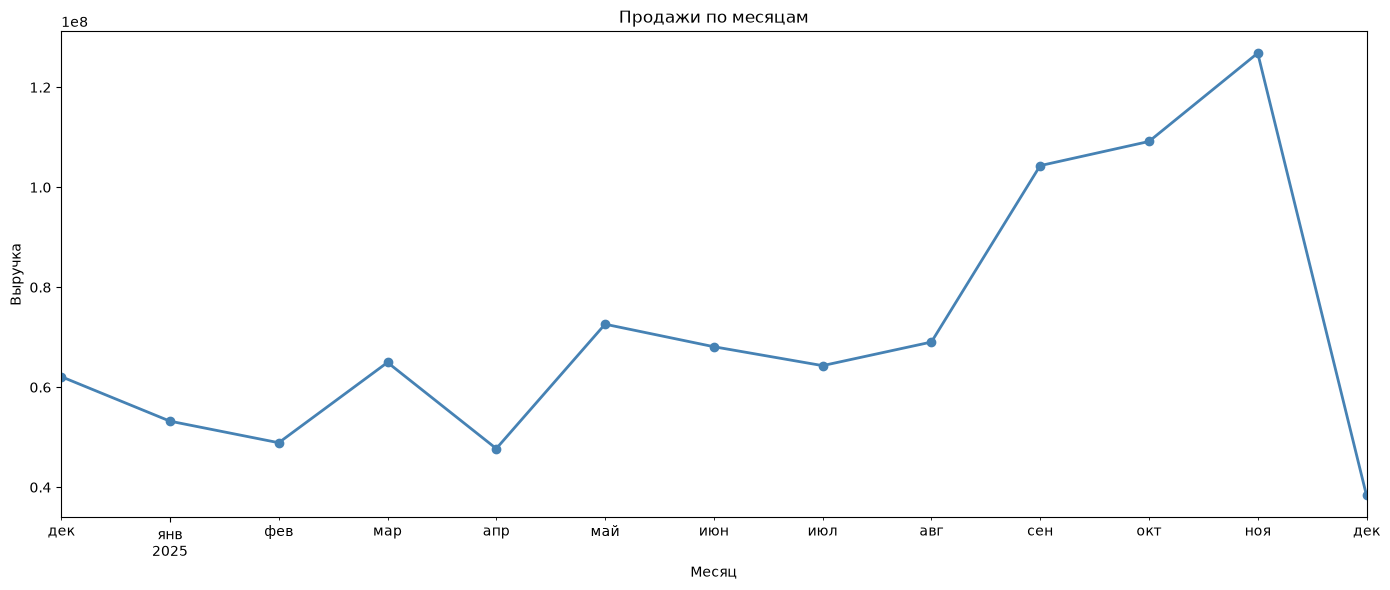

In [193]:
plt.figure(figsize=(14, 6))
monthly.plot(marker='o', color='steelblue', linewidth=2)
plt.title('Продажи по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Выручка')
plt.tight_layout()
plt.show()

Пик ближе к концу 2025 года, данные за декабрь не полные.

## Задание 2. RFM-анализ (Recency, Frequency, Monetary)

In [194]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [195]:
rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
)

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,2,0.00
12347,2,7,482720.00
12348,75,4,201290.88
12349,19,1,196845.60
12350,310,1,37452.80


In [196]:
from sklearn.preprocessing import StandardScaler

In [197]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

In [198]:
import seaborn as sns

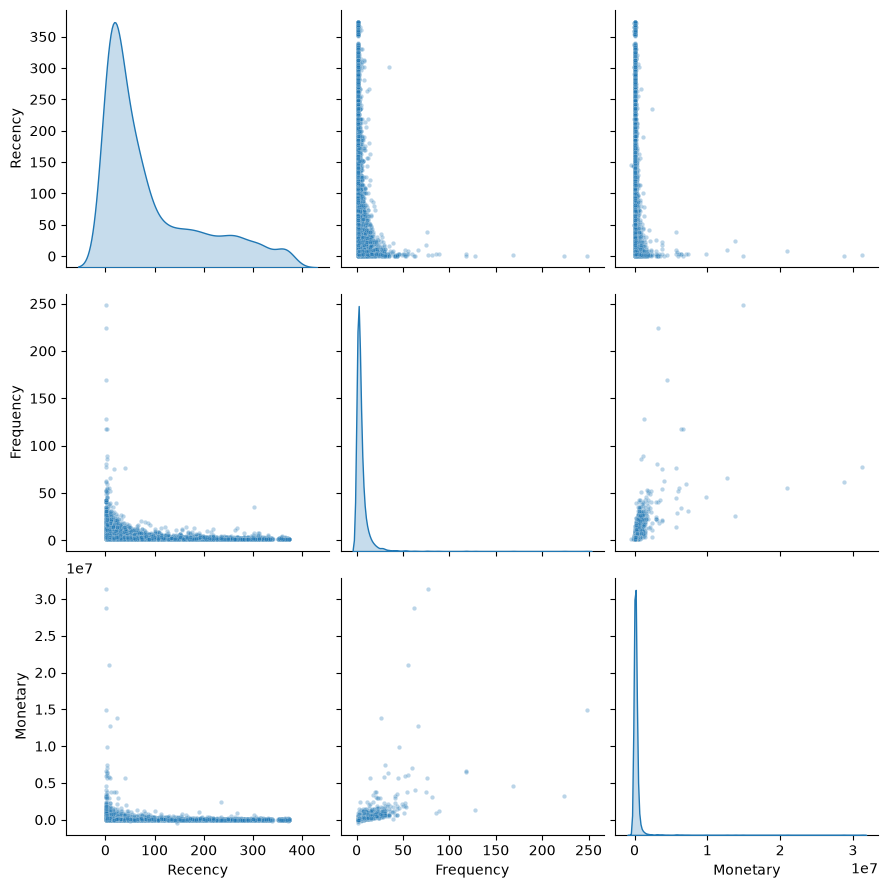

In [199]:
sns.pairplot(rfm, diag_kind='kde', height=3, plot_kws={'alpha': 0.3, 's': 10})

In [200]:
import numpy as np

d:\projects\asu\venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


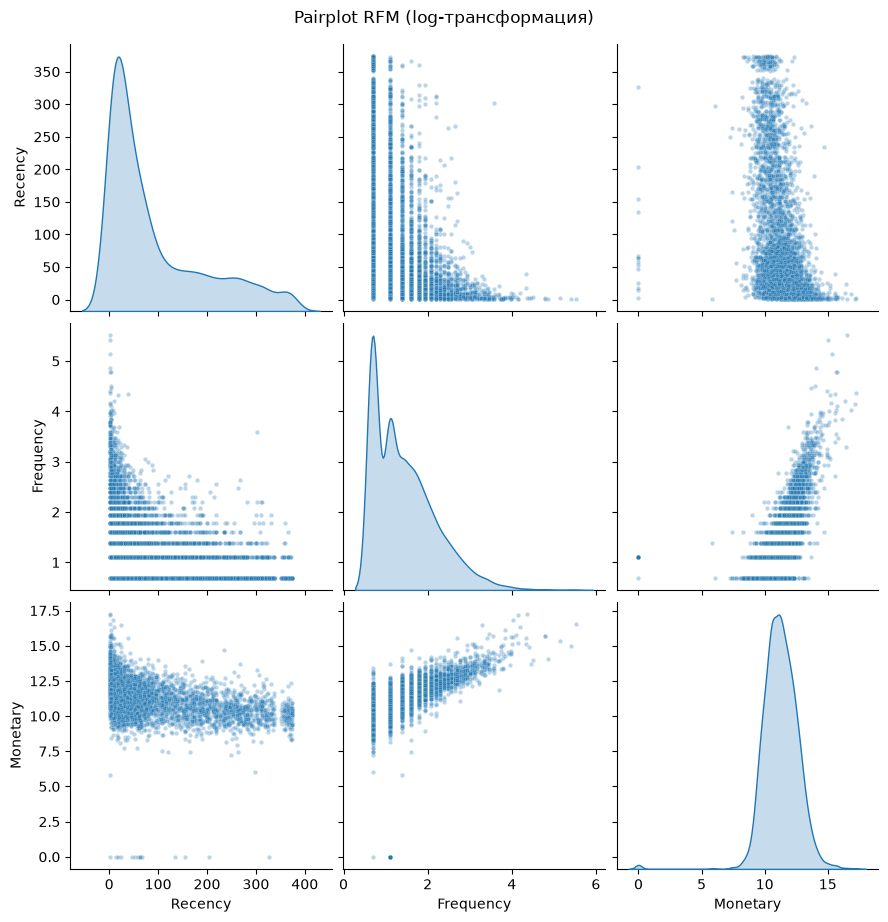

In [201]:
# Логарифмируем Frequency и Monetary
rfm_log = rfm.copy()
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])

# Pairplot на логарифмированных данных
sns.pairplot(rfm_log, diag_kind='kde', height=3, plot_kws={'alpha': 0.3, 's': 10})
plt.suptitle('Pairplot RFM (log-трансформация)', y=1.02)
plt.show()

- На гистограмме R видно много клиентов покупающих недавно.
- На гистограмме F видно два пика, первый пик - клиенты покупающие один раз, второй - больше.
- На гистограмме M видно нормально распределение.
- На F x M видна зависимость - чем чаще покупают тем больше сумма.
- На R x M снизу видны аномалии с около нулевой суммой.

"На глаз" видно две группы, покупающие недавно часто и покупающие давно и редко.

## Задание 3. Определение оптимального числа кластеров

In [202]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

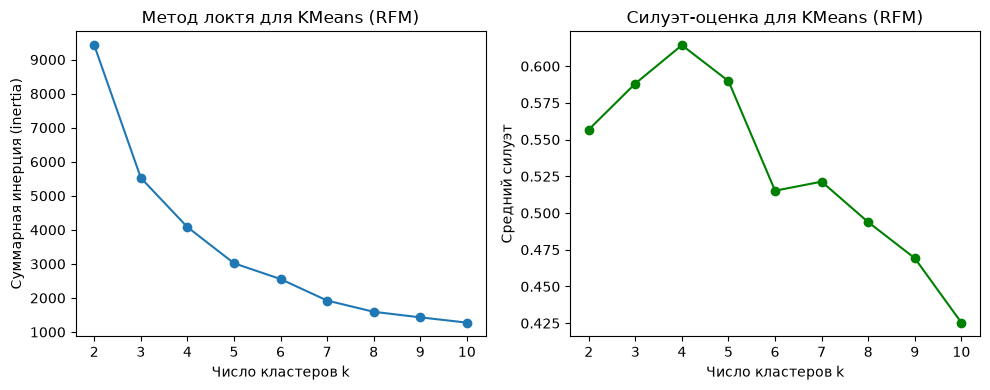

Оптимальное число кластеров по максимальной силуэт-оценке: 4


In [203]:
inertia = []
silhouette_scores = []
K = range(2, 11)
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(rfm_scaled)
    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, labels))

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(K, inertia, marker='o')
plt.xlabel('Число кластеров k')
plt.ylabel('Суммарная инерция (inertia)')
plt.title('Метод локтя для KMeans (RFM)')

plt.subplot(1, 2, 2)
plt.plot(K, silhouette_scores, marker='o', color='green')
plt.xlabel('Число кластеров k')
plt.ylabel('Средний силуэт')
plt.title('Силуэт-оценка для KMeans (RFM)')
plt.tight_layout()
plt.show()

optimal_k = silhouette_scores.index(max(silhouette_scores)) + 2
print(f'Оптимальное число кластеров по максимальной силуэт-оценке: {optimal_k}')

- В данном случае по методу локтя тяжело определить точное k, k от трех до пяти.
- silhouette максимален при k = 4

k = 4 находится в диапазоне метода локтя.

Силуэт часто даёт k = 2, а метод локтя - от k = 3 до k = 5 потому что, silhouette измеряет насколько точки далеки от соседей, а локоть измеряет насколько точки близки к центрам.

Выбираем k = 4, т.к. 4 соответствет отценке silhouette, попадает в метод локтя и согласуется с бизнес логикой - VIP,
постоянные, новые, потерянные.

## Задание 4. KMeans при k = 2, 3, 4, 5

In [204]:

def rfm_Kmeans(k):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(rfm_scaled)
    rfm_log['Cluster'] = labels
    silhouette = silhouette_score(rfm_scaled, labels)
    print(f'k={k}: silhouette = {silhouette:.4f}')
    # Pairplot на логарифмированных данных
    sns.pairplot(
        rfm_log,
        hue='Cluster',
        palette='tab10',
        diag_kind='kde',
        height=3,
        plot_kws={'alpha': 0.4, 's': 10}
    )
    plt.suptitle(f'Pairplot RFM (log), k={k}, silhouette={silhouette:.3f}', y=1.02)
    plt.show()

k=2: silhouette = 0.5568


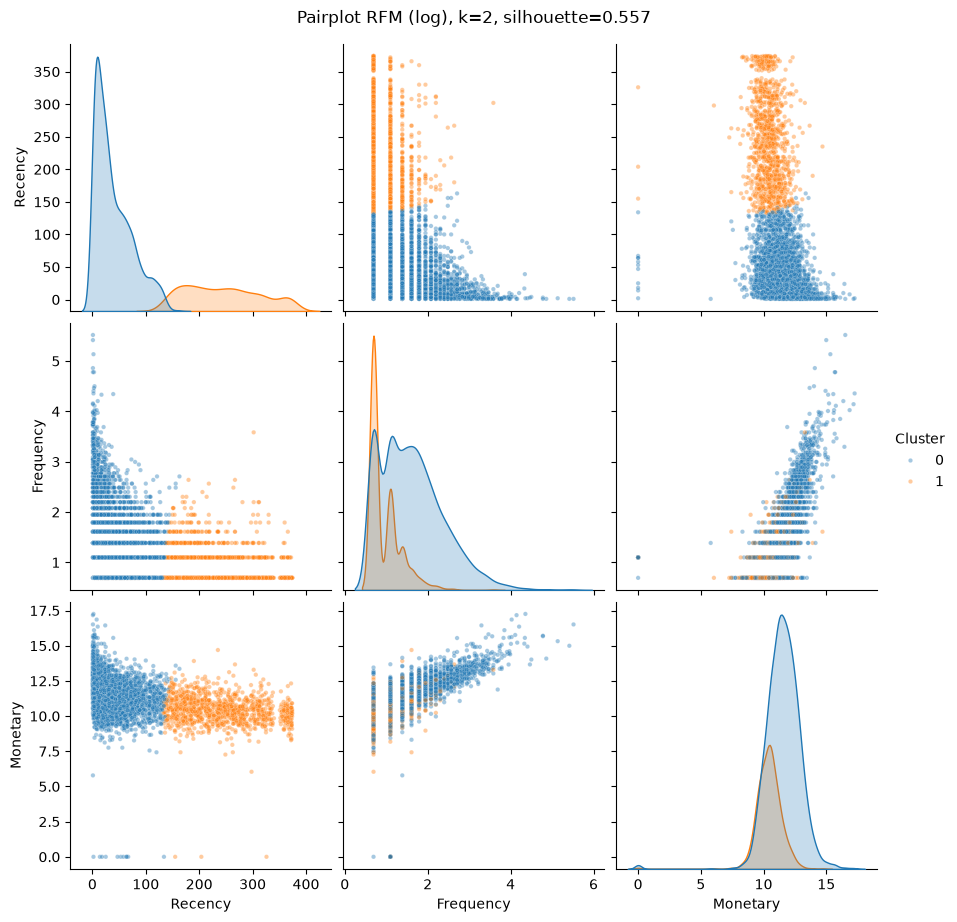

In [205]:
# для k = 2
rfm_Kmeans(2)

k=3: silhouette = 0.5882


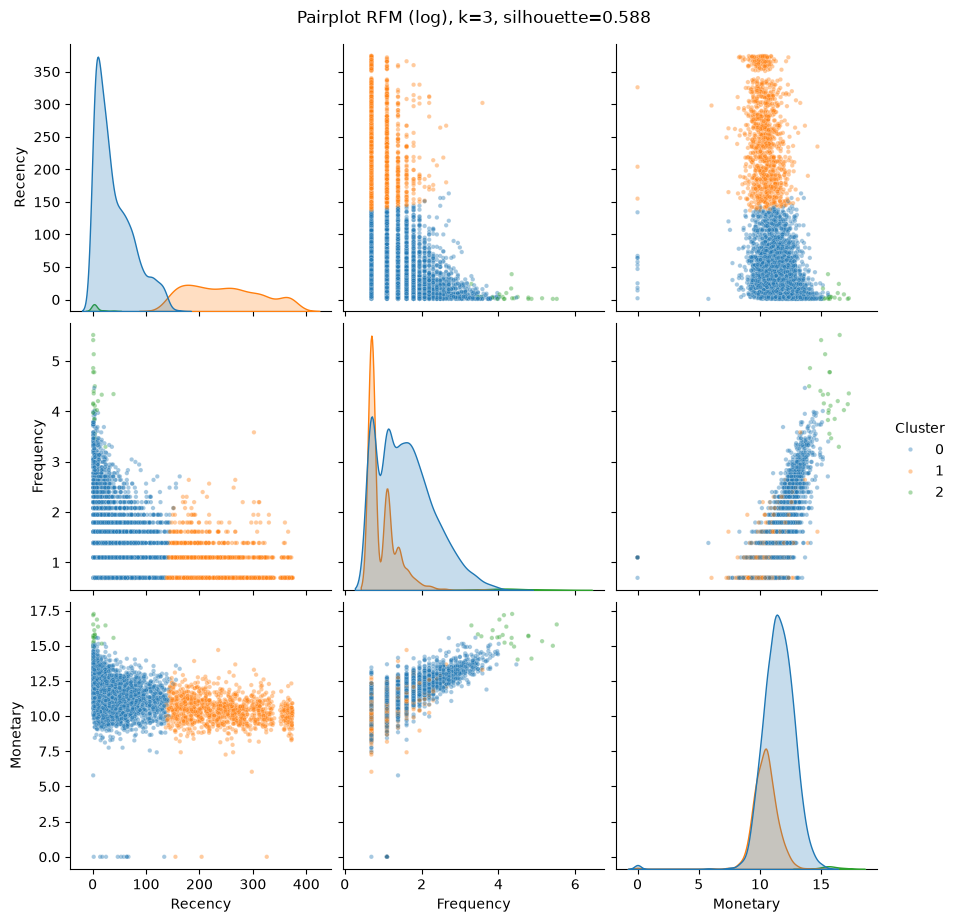

In [206]:
# для k = 3
rfm_Kmeans(3)

k=4: silhouette = 0.6143


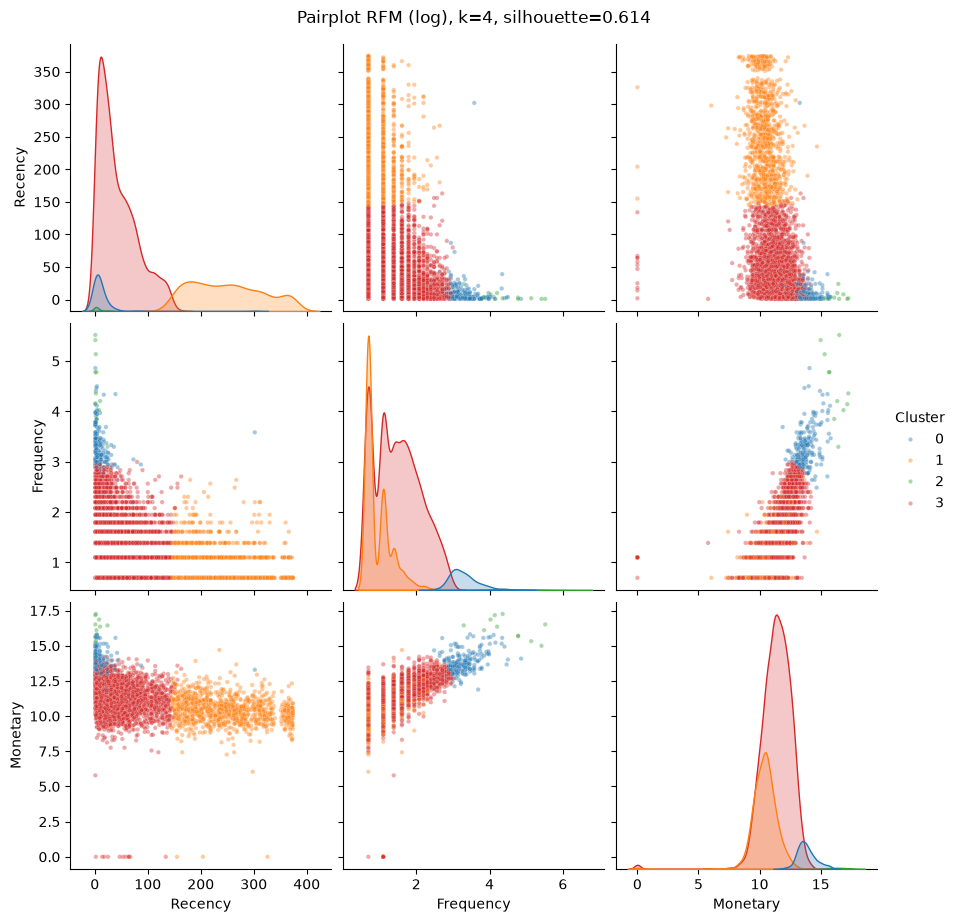

In [207]:
# для k = 4
rfm_Kmeans(4)

k=5: silhouette = 0.5899


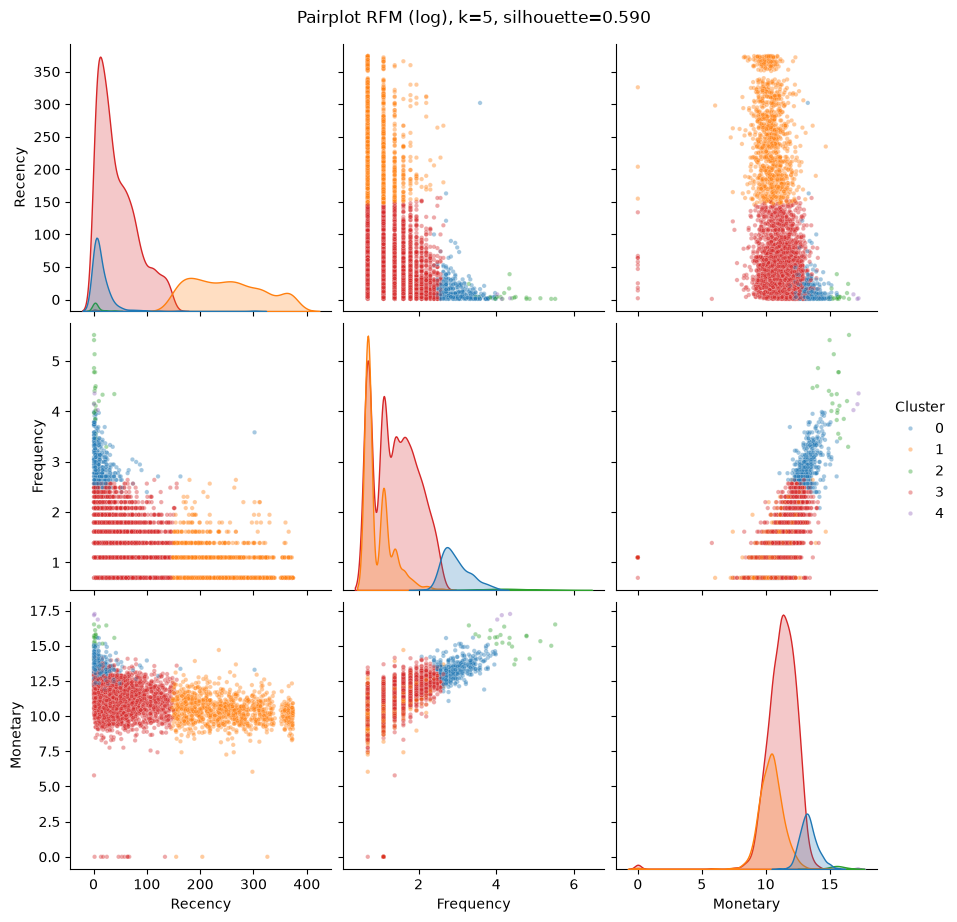

In [208]:
# для k = 5
rfm_Kmeans(5)

#### silhouette plot для всех вариантов k

In [209]:
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm

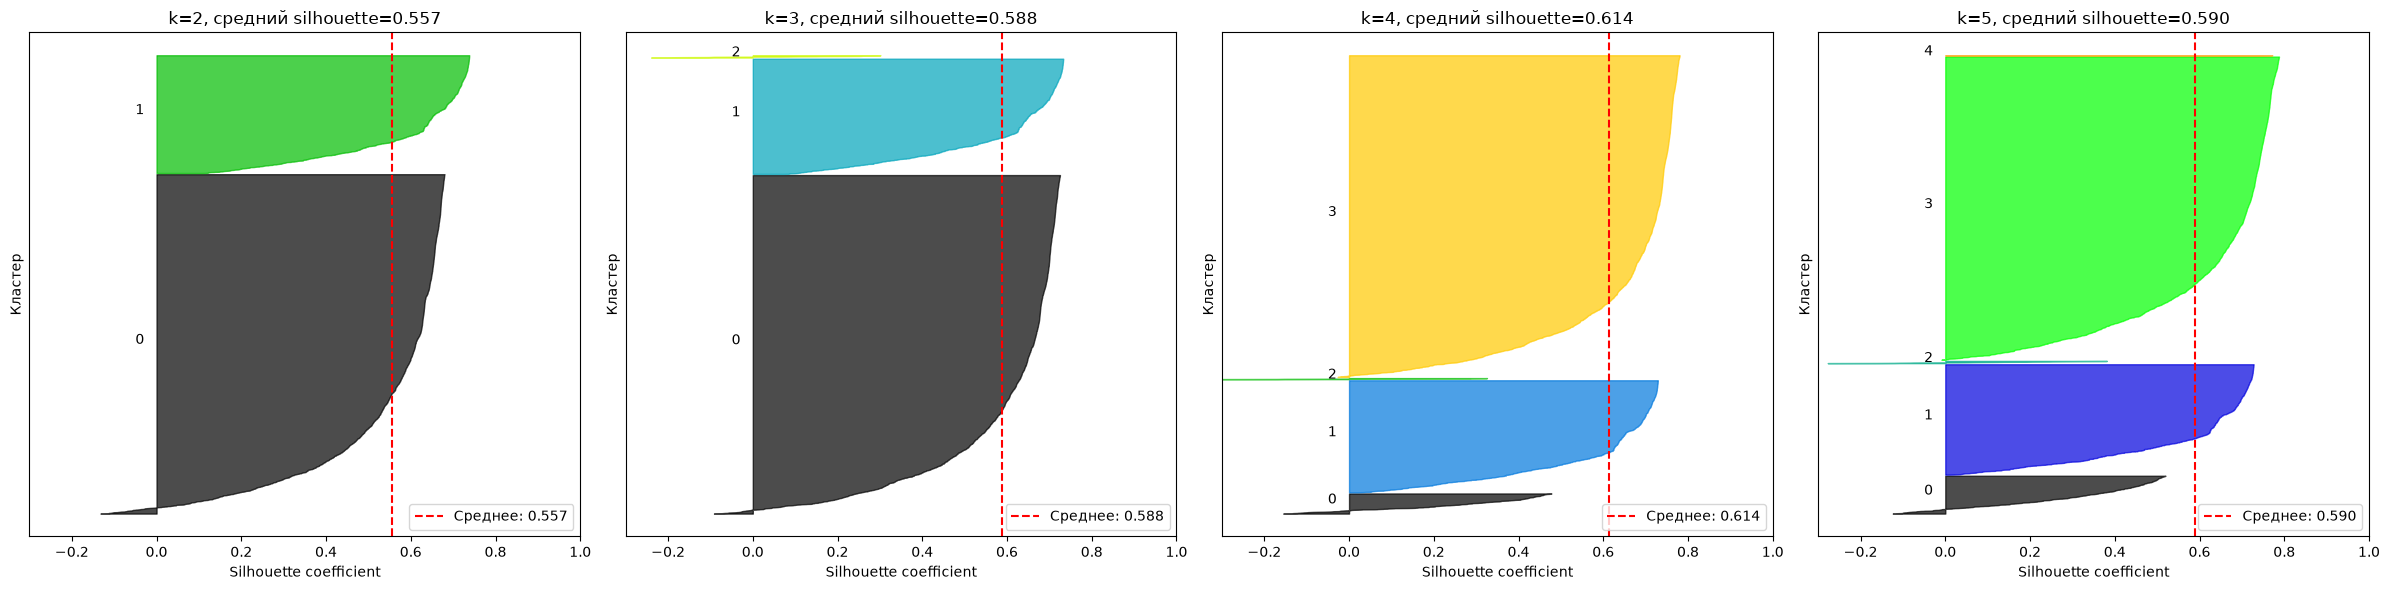

In [210]:
# Функция для silhouette plot
def silhouette_plot(X, k, ax):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X)
    
    sil_vals = silhouette_samples(X, labels)
    sil_avg = silhouette_score(X, labels)
    
    y_lower = 10
    for i in range(k):
        cluster_vals = np.sort(sil_vals[labels == i])
        size = len(cluster_vals)
        y_upper = y_lower + size
        
        color = cm.nipy_spectral(float(i) / k)
        ax.fill_betweenx(np.arange(y_lower, y_upper),
                         0, cluster_vals,
                         facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size, str(i))
        y_lower = y_upper + 10
    
    ax.axvline(x=sil_avg, color='red', linestyle='--',
               label=f'Среднее: {sil_avg:.3f}')
    ax.set_xlabel('Silhouette coefficient')
    ax.set_ylabel('Кластер')
    ax.set_title(f'k={k}, средний silhouette={sil_avg:.3f}')
    ax.set_yticks([])
    ax.legend(loc='lower right')
    ax.set_xlim([-0.3, 1])

# Строим для k = 2, 3, 4, 5
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

for ax, k in zip(axes, [2, 3, 4, 5]):
    silhouette_plot(rfm_scaled, k, ax)

plt.tight_layout()
plt.show()

- Средний силуэт выше при k = 4.
- На всех графиках есть точки с отрицательным силуэтом.
- У кластеров мечи не ровные и есть выбивающиеся кластеры.

#### Профиль кластеров для всех k

In [212]:
for k in [2, 3, 4, 5]:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(rfm_scaled)
    
    rfm_temp = rfm.copy()
    rfm_temp['Cluster'] = labels
    
    profile = rfm_temp.groupby('Cluster').agg(
        Recency=('Recency', 'mean'),
        Frequency=('Frequency', 'mean'),
        Monetary=('Monetary', 'mean'),
        Size=('Recency', 'count')
    ).round(1)
    
    profile = profile.sort_values('Monetary', ascending=False)
    
    # print(f'{'='*50}')
    print(f'k = {k}')
    print(profile)

k = 2
         Recency  Frequency  Monetary  Size
Cluster                                    
0           39.2        6.2  268547.8  3245
1          244.2        1.9   51614.7  1127
k = 3
         Recency  Frequency   Monetary  Size
Cluster                                     
2            6.1       86.9  9165616.0    23
0           40.1        5.6   204046.1  3244
1          246.4        1.8    51468.6  1105
k = 4
         Recency  Frequency    Monetary  Size
Cluster                                      
2            5.1      109.9  13922978.3    11
0           10.8       28.5   1362845.6   194
3           42.8        4.4    147949.9  3090
1          248.9        1.8     50972.4  1077
k = 5
         Recency  Frequency    Monetary  Size
Cluster                                      
4            3.7       64.7  27007294.7     3
2            6.2       88.4   6108544.5    22
0           14.8       19.7    794646.5   365
3           44.8        3.8    126766.3  2919
1          250.3       

- При k = 4 силуэт выше.
- При k = 4 интерпретируемы как бизнес-сегменты.
- При k = 4, судя по графику, кластер 2 перетягивает силуэт вниз. Monetary = 13922978.3 - выброс.